(https://github.com/sihsieh65-tech/cs82a-portfolio/tree/main/Module5)

loading libraries and first data set

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('chickwts.csv')
df

,Unnamed: 0,weight,feed
0,1,179,horsebean
1,2,160,horsebean
2,3,136,horsebean
3,4,227,horsebean
4,5,217,horsebean
...,...,...,...
66,67,359,casein
67,68,216,casein
68,69,222,casein
69,70,283,casein


Step 1: Group means for chick feeds

In [2]:
df.groupby("feed")["weight"].mean().sort_values()

feed
horsebean    160.200000
linseed      218.750000
soybean      246.428571
meatmeal     276.909091
casein       323.583333
sunflower    328.916667
Name: weight, dtype: float64

Step 2: Sorted bar chart: I first plot the data just to make sure my labelling looked ok. Then I manipulated it to sort by mean. 

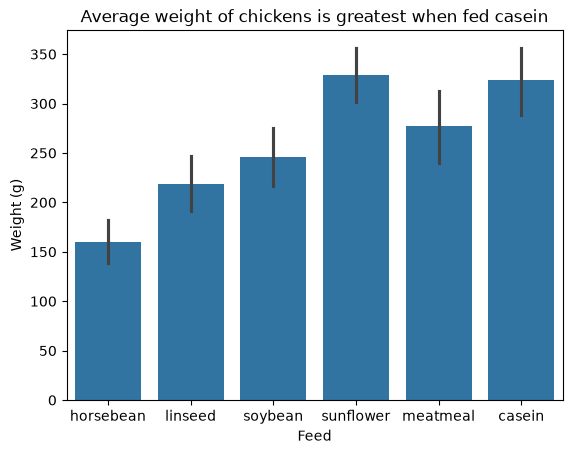

In [3]:
sns.barplot(data=df, x="feed", y="weight")
plt.title("Average weight of chickens is greatest when fed casein")
plt.xlabel("Feed")
plt.ylabel("Weight (g)")
plt.show()

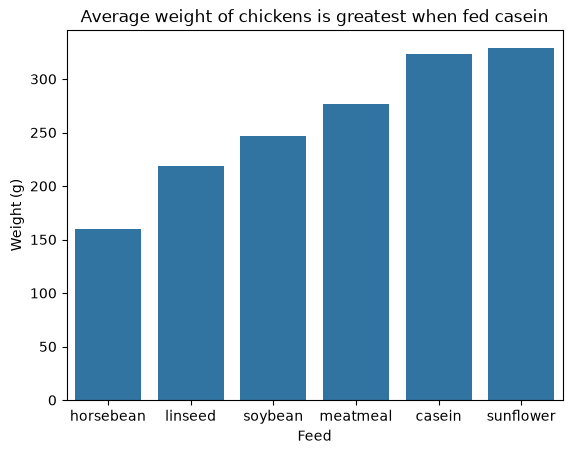

In [4]:
df_sorted = df.groupby('feed')['weight'].mean().reset_index()
df_sorted = df_sorted.sort_values(by='weight', ascending=True)
sns.barplot(data=df_sorted, x="feed", y="weight")
plt.title("Average weight of chickens is greatest when fed casein")
plt.xlabel("Feed")
plt.ylabel("Weight (g)")
plt.show()

Step 3: Histogram of all weights

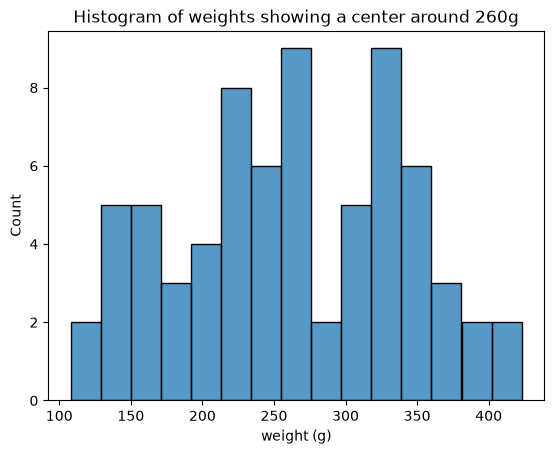

In [5]:
sns.histplot(data=df, x="weight", bins=15)
plt.title("Histogram of weights showing a center around 260g")
plt.xlabel("weight (g)")
plt.show()

Step 4: Line chart of museum visitors. I changed the data column into a date data type then comfirmed it. I then did a histogram of the visitor data just for practice. 

In [6]:
df2 = pd.read_csv('museum_visitors.csv')
df2["Total"] = df2["Avila Adobe"] + df2["Firehouse Museum"] + df2["Chinese American Museum"] + df2["America Tropical Interpretive Center"]
df2

,Date,Avila Adobe,Firehouse Museum,Chinese American Museum,America Tropical Interpretive Center,Total
0,2014-01-01,24778,4486,1581,6602,37447
1,2014-02-01,18976,4172,1785,5029,29962
2,2014-03-01,25231,7082,3229,8129,43671
3,2014-04-01,26989,6756,2129,2824,38698
4,2014-05-01,36883,10858,3676,10694,62111
5,2014-06-01,29487,5751,2121,11036,48395
6,2014-07-01,32378,5406,2239,13490,53513
7,2014-08-01,37680,8619,1769,9139,57207
8,2014-09-01,28473,61192,1073,5661,96399
9,2014-10-01,27995,6488,1979,7356,43818


In [7]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype
---  ------                                --------------  -----
 0   Date                                  59 non-null     str  
 1   Avila Adobe                           59 non-null     int64
 2   Firehouse Museum                      59 non-null     int64
 3   Chinese American Museum               59 non-null     int64
 4   America Tropical Interpretive Center  59 non-null     int64
 5   Total                                 59 non-null     int64
dtypes: int64(5), str(1)
memory usage: 2.9 KB


In [8]:
df2["Date"] = pd.to_datetime(df2["Date"])

In [9]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   Date                                  59 non-null     datetime64[us]
 1   Avila Adobe                           59 non-null     int64         
 2   Firehouse Museum                      59 non-null     int64         
 3   Chinese American Museum               59 non-null     int64         
 4   America Tropical Interpretive Center  59 non-null     int64         
 5   Total                                 59 non-null     int64         
dtypes: datetime64[us](1), int64(5)
memory usage: 2.9 KB


<Axes: xlabel='Total', ylabel='Count'>

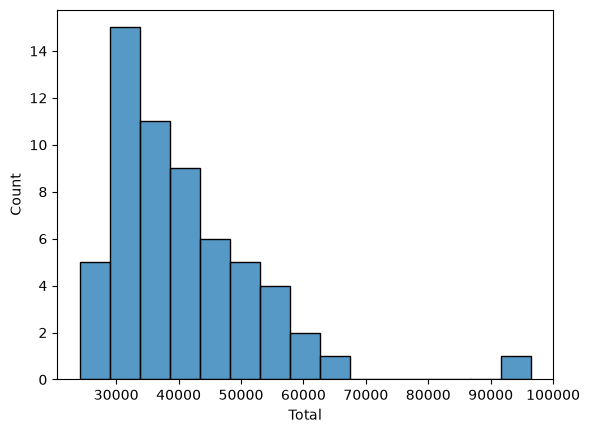

In [10]:
sns.histplot(data=df2, x="Total", bins=15)

Text(0.5, 1.0, 'Total visitor counts have been declining since 2014')

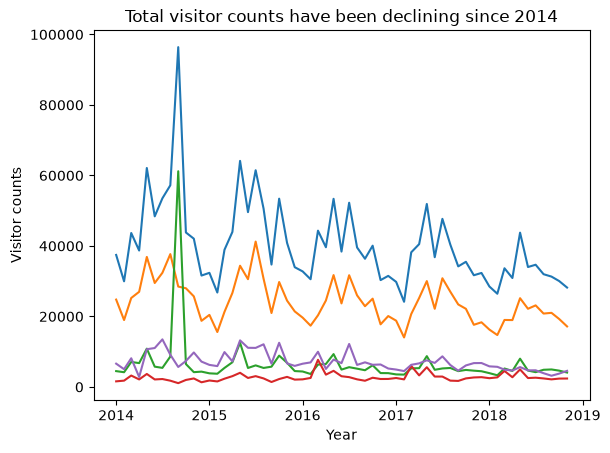

In [11]:
sns.lineplot(data=df2, x="Date", y="Total")
sns.lineplot(data=df2, x="Date", y="Avila Adobe")
sns.lineplot(data=df2, x="Date", y="Firehouse Museum")
sns.lineplot(data=df2, x="Date", y="Chinese American Museum")
sns.lineplot(data=df2, x="Date", y="America Tropical Interpretive Center")
plt.ylabel("Visitor counts")
plt.xlabel("Year")
plt.title("Total visitor counts have been declining since 2014")

In [12]:
df2['year'] = df2['Date'].dt.year

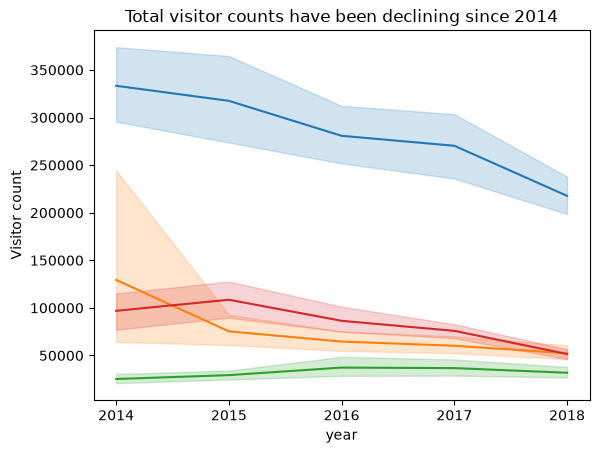

In [13]:
import matplotlib.ticker as ticker
ax= sns.lineplot(data=df2, x='year', y='Avila Adobe', estimator=sum)
ax= sns.lineplot(data=df2, x='year', y='Firehouse Museum', estimator=sum)
ax= sns.lineplot(data=df2, x='year', y='Chinese American Museum', estimator=sum)
ax= sns.lineplot(data=df2, x='year', y="America Tropical Interpretive Center", estimator=sum)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.title("Total visitor counts have been declining since 2014")
plt.ylabel("Visitor count")
plt.show()

Step 5: Scatter and heatmap on your sales data

<Axes: >

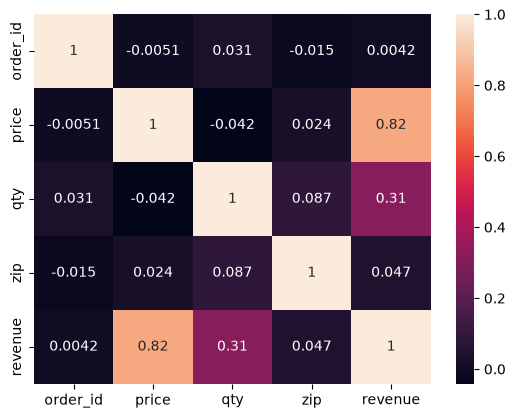

In [14]:
df3 = pd.read_csv('sales_clean.csv')
df3["revenue"] = df3["price"] * df3["qty"]
sns.heatmap(df3.corr(numeric_only=True), annot=True)

Step 6: State the hypothesis
The null hypothesis is that there is no difference between the average weight of a horsebean fed chicken vs a sunflower fed chicken.

Step 7: Run the t-test

In [15]:
from scipy.stats import ttest_ind
a = df[df["feed"] == "sunflower"]["weight"]
b = df[df["feed"] == "horsebean"]["weight"]
ttest_ind(a, b)

TtestResult(statistic=np.float64(8.848346742516636), pvalue=np.float64(2.3743507676837164e-08), df=np.float64(20.0))

Step 8: The conclusion sentence
Based on the t-test result where the t was above 8 and the p value was far below 0.05 i would reject the null-hypothesis. There is a statistically significant difference in the average weight of chickens fed sunflower vs horsebean. 

Step 9: Honest-chart audit. 
In the chicken weight barcharts I ensured that the y-axis was at zero, this is to ensure that there are no exagerated differences between the bars. For the visitor data I grouped the data by year to show the steady annual decline in visitors, otherwise it is really hard to see in tbe month-by-month data as it is noisy. 